In [1]:
from pathlib import Path
import h5py
#import sys
#local_path = Path("C:/Users/michi/Documents/Git/star_shadow")  # pas aan
#sys.path.insert(0, str(local_path))
#import star_shadow as sts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
base = Path("C:/Users/michi/Documents/Git/data")  # gebruik / hier
base.mkdir(parents=True, exist_ok=True)
print(base)

C:\Users\michi\Documents\Git\data


In [3]:
file = str(base) + '/stitched_year1/lc_tic177162802_corrected_stitched.csv'

df = pd.read_csv(file)
print(df.keys())
times = np.array(df['time'])
flux = np.array(df['flux'])
flux_error = np.array(df['flux_err'])

Index(['time', 'flux', 'flux_err', 'centroid_col', 'centroid_row', 'cadenceno',
       'quality'],
      dtype='object')


In [4]:
file_name = "/Users/michi/Documents/Git/SPB-astroseismology/results_spb1_year1.hdf5"

In [ ]:

i_sectors = np.array([[0, len(times)]])
t_tot = np.ptp(times)  # total time base of observations
t_mean = np.mean(times)  # mean time of observations
t_mean_s = np.array([np.mean(times[s[0]:s[1]]) for s in i_sectors])  # mean time per observation sector
t_int = np.median(np.diff(times))  # integration time, taken to be the median time step
t_stats = [t_tot, t_mean, t_mean_s, t_int]

NameError: name 'np' is not defined

In [7]:
sts.iterative_prewhitening(times=times, signal=flux, signal_err=flux_error, i_sectors=i_sectors, t_stats=t_stats, file_name=file_name, data_id='testspb1', overwrite=True, verbose=True)

Looking for frequencies
N_f= 0, BIC= -3649035.72 (delta= N/A) - start extraction
N_f= 207, BIC= -3746016.00 (delta= 96980.28) - end extractionf= 4.001091, a= 0.0000210.00003625
Single frequencies removed: 4
N_f= 203, BIC= -3746010.28 (delta= 32.77)
Frequency sets replaced by a single frequency: 0 (0 frequencies). 
N_f= 203, BIC= -3746010.28 (delta= 0.00)
Number of frequencies passed criteria: 79 of 203. Candidate harmonics: 0, of which 0 passed.
Extraction of sinusoids complete.
203 frequencies, 611 free parameters, BIC: -3746010.29. Time taken: 3264.2s



(array([-2.62317343e-05]),
 array([-2.9355992e-09]),
 array([1.07820347e+00, 8.86402115e-01, 1.54218139e+00, 1.13939542e+00,
        1.08583511e-01, 1.47997889e+00, 9.82092944e-01, 1.18680672e+00,
        9.44818580e-01, 1.33329111e+00, 1.19260131e+00, 7.35277120e-01,
        4.94645608e-01, 8.62159700e-01, 1.61233541e+00, 1.23473372e-01,
        1.54309402e+00, 7.88262530e-01, 1.68874471e+00, 7.06864268e-01,
        1.38134409e-01, 1.52478205e-01, 1.28669379e+00, 1.67640530e+00,
        9.45580946e-02, 8.38352543e-01, 3.19021102e+00, 1.55423315e-01,
        1.41651009e-01, 1.49125956e+00, 6.43625808e-01, 9.44274791e-01,
        8.62949009e-01, 1.90544915e-01, 8.86695450e-01, 1.28271726e+00,
        1.90348840e+00, 6.35060665e-01, 1.17278016e+00, 1.79502556e-01,
        8.20297096e-01, 2.07881255e-01, 1.18492755e-01, 3.55397817e-02,
        2.94071306e+00, 1.46663122e-01, 7.35747669e-01, 7.49879338e-01,
        7.06437358e-01, 2.84062411e+00, 1.22474858e+00, 7.67823978e-01,
        1.2

In [5]:
import h5py
itprw = h5py.File(file_name)
list(itprw.keys())

['a_n',
 'a_n_err',
 'a_n_hdi',
 'c_err',
 'c_hdi',
 'const',
 'cosi',
 'depth_1',
 'depth_2',
 'e',
 'ecosw',
 'esinw',
 'f_n',
 'f_n_err',
 'f_n_hdi',
 'i',
 'i_sectors',
 'log_rr',
 'log_sb',
 'p_orb',
 'passed_b',
 'passed_h',
 'passed_sigma',
 'passed_snr',
 'ph_n',
 'ph_n_err',
 'ph_n_hdi',
 'phi_0',
 'r_rat',
 'r_sum',
 'ratios_1',
 'ratios_2',
 'ratios_3',
 'ratios_4',
 'sb_rat',
 'sl_err',
 'sl_hdi',
 'slope',
 't_1',
 't_1_1',
 't_1_2',
 't_2',
 't_2_1',
 't_2_2',
 't_b_1_1',
 't_b_1_2',
 't_b_2_1',
 't_b_2_2',
 't_zero',
 'w']

In [6]:
import math

def two_space_prefixed(v: float):
    """Maak string met 10 decimalen en max. 2 leidende spaties,
    waarbij die spaties worden ingenomen door minteken/tiental/honderdtal."""
    s = f"{v:.10f}"
    prefix = 2
    if v < 0:
        prefix -= 1  # '-' neemt 1 plek
    # aantal cijfers in het integer-deel
    int_digits = len(str(int(abs(v)))) if abs(v) >= 1 else 1
    if int_digits >= 2:
        prefix -= 1
    if int_digits >= 3:
        prefix -= 2
    if prefix < 0:
        prefix = 0
    return (" " * prefix) + s

def write_amigo(df, path):
    """
    Schrijft een .amigo bestand met:
      - tab-delimiters
      - elke kolom gestart met twee spaties (opgevuld door cijfers/minteken)
      - header: '# per' gevolgd door '\t  e_per\t  ampl\t ...'
      - afsluitende '#'-lijn over de volledige breedte van de langste datarij
    """
    path = Path(path)

    cols_wanted = ["per", "e_per", "ampl", "e_ampl", "phase", "e_phase", "stopcrit"]

    if "stopcrit" not in df.columns:
        df["stopcrit"] = 4.0

    missing = [c for c in cols_wanted if c not in df.columns]
    if missing:
        raise ValueError(f"Ontbrekende kolommen: {missing}")

    # Header opbouwen: eerste veld '# per', overige '  naam', gescheiden door tabs
    headers = ["per", "e_per", "ampl", "e_ampl", "phase", "e_phase", "stopcrit"]
    header_line = "# "

    header_line = "# " + "\t  ".join(header + " " * (13 - len(header)) for header in headers)

    max_len = len(header_line)  # voor afsluitende ***-lijn

    with path.open("w", encoding="utf-8", newline="\n") as f:
        # header
        f.write(header_line + "\n")

        # datarijen
        for _, row in df[headers].iterrows():
            fields = [two_space_prefixed(float(row[c])) for c in headers]
            line = "\t".join(fields)
            f.write(line + "\n")
            if len(line) > max_len:
                max_len = len(line)

        # afsluitende rij van '#'
        f.write("*" * (max_len-1) + "\n")

    return str(path)

In [8]:
df = pd.DataFrame()
freq = np.array(itprw['f_n'])
freq_err = np.array(itprw['f_n_err'])

df['per'] = 1/ freq
df['e_per'] = freq_err / (freq ** 2)
df['ampl'] = np.array(itprw['a_n'])
df['e_ampl'] = np.array(itprw['a_n_err'])
df['phase'] = np.array(itprw['ph_n'])
df['e_phase'] = np.array(itprw['ph_n_err'])
df['stopcrit'] = np.ones(len(freq))*4

df_filtered = df[df['per'] < 1.3].nlargest(15,"ampl")

#write_amigo(df_filtered, "TIC_177162802_spacings.amigo")

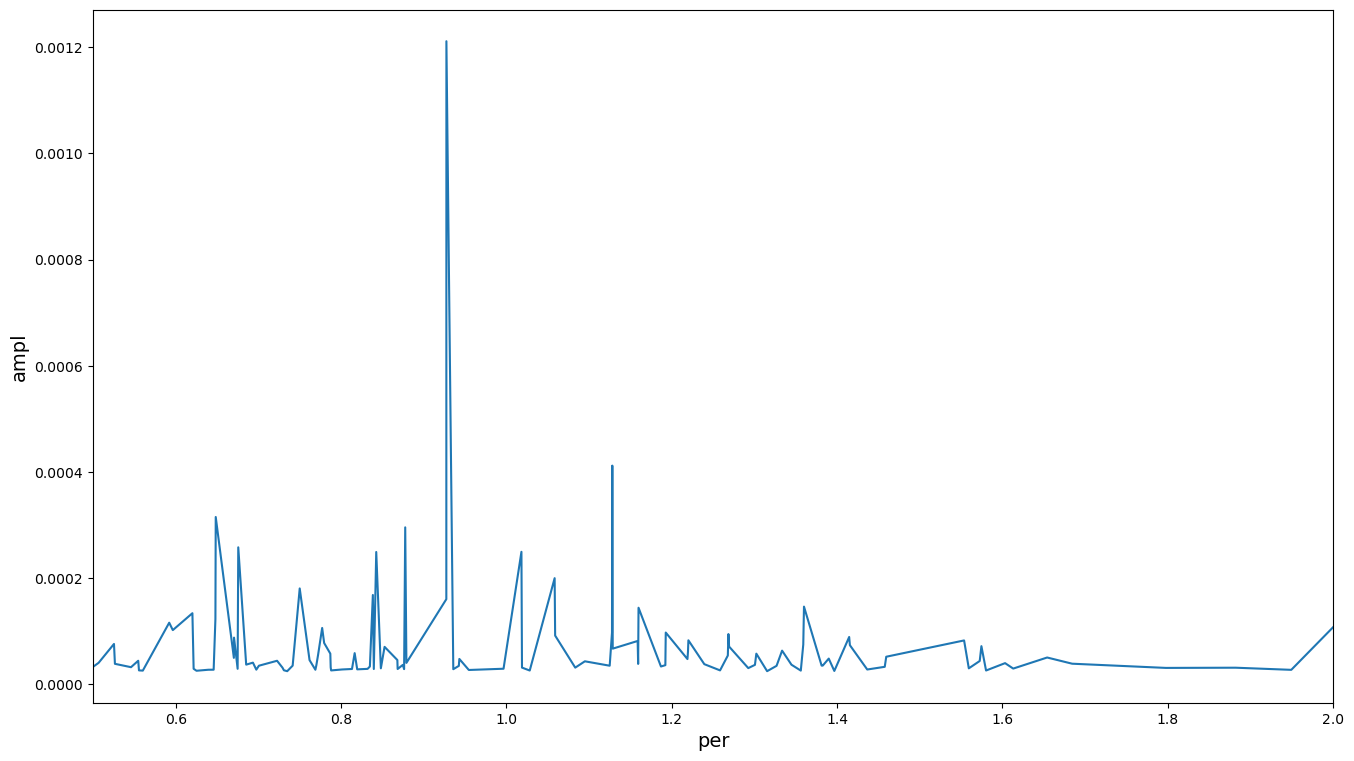

In [9]:
df_sorted = df.sort_values(by='per')
plt.plot(df_sorted['per'], df_sorted['ampl'])
plt.xlabel("per")
plt.ylabel("ampl")
plt.xlim(0.5,2)
plt.show()

np.savetxt(
    "output.txt",
    np.column_stack((df_sorted['per'], df_sorted['ampl'])),
    fmt="%.10f",
    header="per   ampl"
)

In [9]:
freq = np.array(itprw['f_n'])
tic = 177162802

df['amp'] = np.array(itprw['a_n'])
df['frequency'] = freq
df['phase'] = np.array(itprw['ph_n'])
df['const'] = np.ones(len(freq))*0.0
df['per'] = 1 / freq
df['e_ampl'] = np.array(itprw['a_n_err'])
df['e_frequency'] = np.array(itprw['f_n_err'])
df['e_phase'] = np.array(itprw['ph_n_err'])
df['tic'] = np.ones(len(freq))*tic
df['stopcrit'] = np.ones(len(freq))*4

df.to_csv(f"pw_tic{tic}_year1.csv", index=False)